In [45]:
from __future__ import annotations
import operator
from typing import TypedDict,Annotated,List
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_groq import ChatGroq
from pathlib import Path


In [4]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    
)

## Creating Pydantic model of Task 

In [5]:
class Task(BaseModel):
    id: int
    title: str
    breif: str = Field(..., description="What to cover") # Elipse ... means required field

## Creating Pydantic Model of Plan

In [6]:
class Plan(BaseModel):
    blog_title: str
    tasks : List[Task]

## State of Agent

In [15]:
class State(TypedDict):
    topic: str # given by the user
    plan: Plan # plan for writing the blog, given by the LLM
    sections: Annotated[List[str],operator.add]# add is used for concatenating the list of sections
    final:str


## Defining Orchestrator Node

In [16]:
def orchestrator(state:State)->dict:
    plan = llm.with_structured_output(Plan).invoke( # this line force the LLM to always give output in the form of plan object
        [
            SystemMessage(content="Create a blog plan 5-7 sections on the following topic."),
            HumanMessage(content=f" topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

## Function to trigger worker node

In [17]:
def fanout(state: State):
    return [Send("worker",{'task':task,"topic":State['topic'],"plan":state['plan']}) 
            for task in state['plan'].tasks
            ]
# jitne topics hain utne workers trigger honge, har worker ko ek task milega, aur uske sath topic aur plan bhi milega taki wo apne task ko ache se samajh sake
# ye kaam Send () k through ho ga jo lanchain provide krta hai ... ye topics k hissab se worker nodes ko trigger kre ga aur un ko data bhi provide kre ga 

## Defining Worker Node


In [18]:
def worker(payload:dict)->dict:

    # Payload contains the information that is send by Send() when it triggers the worker node, in our case it contains the task, topic and plan
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    section_content = llm.invoke([
        SystemMessage("Write one clean markdown section."),
        HumanMessage(content = 
                     f"BlogTitle: {plan.blog_title}\n"
                     f"Topic: {topic}\n"
                     f"Section Title: {task.title}\n"
                    f"Section Brief: {task.breif}\n"
                    "Return only the section content in markdwn"
                     )
    ]).content.strip()
    return {"sections": [section_content]} # ye section content ek list k form me return ho ga taki orchestrator me use add operator k through concatenate kr sake

## Defining the reducer node

In [46]:
def reducer(state:State) -> dict:
    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip() # ye state me jitne bhi sections hain unko concatenate krke ek body bana dega
    final = f"# {title}\n\n{body}" # ye final blog post ka format hoga jisme title h1 tag me hoga aur uske niche body hogi  

    # Save the final blog post to a markdown file

    filename = title.replace(" ","_").lower() + ".md"
    output_path = Path(filename)
    output_path.write_text(final,encoding = "utf-8")
        
    return {"final": final}

## Creating Graph

In [47]:
graph = StateGraph(State)
 
## Adding Nodes in the graph
graph.add_node("orchestrator",orchestrator)
graph.add_node("worker",worker)
graph.add_node("reducer",reducer)

## Creating edges between the nodes
graph.add_edge(START,"orchestrator")
graph.add_conditional_edges("orchestrator",fanout,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)

# Compiling the graph to create an executable application

app = graph.compile()

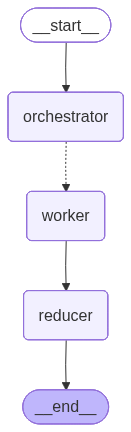

In [24]:
app

## Testing

In [48]:
out = app.invoke({"topic":"Agentic AI"})

In [37]:
print(out['plan'])

blog_title='The Rise of Agentic AI: Understanding the Future of Artificial Intelligence' tasks=[Task(id=1, title='Introduction to Agentic AI', breif='Define agentic AI, its benefits, and its applications'), Task(id=2, title='History of Agentic AI', breif='Trace the development of agentic AI from its roots to current advancements'), Task(id=3, title='Key Features of Agentic AI', breif='Discuss the key characteristics of agentic AI, such as autonomy and self-awareness'), Task(id=4, title='Applications of Agentic AI', breif='Explore real-world applications of agentic AI, including healthcare, finance, and education'), Task(id=5, title='Ethical Considerations of Agentic AI', breif='Discuss the ethics of agentic AI, including accountability, transparency, and bias'), Task(id=6, title='Future of Agentic AI', breif='Speculate on the potential future developments and implications of agentic AI'), Task(id=7, title='Conclusion and Call to Action', breif='Summarize the key points and encourage re

In [38]:
print(out['final'])

# The Rise of Agentic AI: Understanding the Future of Artificial Intelligence

**Introduction to Agentic AI**

Agentic AI, a subfield of artificial intelligence (AI), refers to the development of intelligent agents that can interact and act independently in complex environments. These agents are designed to learn, reason, and adapt to new situations, much like humans.

### Benefits of Agentic AI

1. **Improved Decision Making**: Agentic AI enables machines to make decisions based on their understanding of a situation, reducing the need for human intervention.
2. **Enhanced Autonomy**: By allowing AI agents to act independently, organizations can automate routine tasks and free up human resources for higher-value activities.
3. **Increased Efficiency**: Agentic AI can streamline processes, reduce costs, and improve productivity by optimizing resource allocation and minimizing errors.

### Applications of Agentic AI

1. **Robotics and Autonomy**: Agentic AI is being used in robotics, sel